In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


# Data Collection

In [2]:
df = pd.read_csv("loan.csv")
df.head(2)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


In [3]:
# Before Encoding
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [4]:
df.describe()
# give info ONLY about Numerical columns

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [5]:
df.shape
# gives (no. of rows, no. of cols)

(614, 13)

In [6]:
df.size
# no. of rows * no. of cols = total no. of elements present

7982

# Data Cleaning

In [7]:
print(df.duplicated().sum())

0


In [8]:
df.drop("Loan_ID", axis=1, inplace=True)
df.head(2)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


In [9]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df.drop(['ApplicantIncome','CoapplicantIncome'], axis=1, inplace=True)

In [10]:
df.head(2)

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,Male,No,0,Graduate,No,NaN,360.0,1.0,Urban,Y,5849.0
1,Male,Yes,1,Graduate,No,128.0,360.0,1.0,Rural,N,6091.0


# Handling Missing Values

In [11]:
df.isnull().sum()

Gender              13
Married              3
Dependents          15
Education            0
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
Property_Area        0
Loan_Status          0
Total_Income         0
dtype: int64

In [12]:
# Filling all the Categorical columns with their Mode
for col in df.select_dtypes(include=['object']).columns:
    most_freq = df[col].mode()[0]
    df[col] = df[col].fillna(most_freq)
    df[col] = df[col].fillna(most_freq)

C:\Users\user\AppData\Local\Temp\ipykernel_14960\726615801.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


In [13]:
# Filling all the Numerical columns with their Mode
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [14]:
df.isnull().sum()

Gender              0
Married             0
Dependents          0
Education           0
Self_Employed       0
LoanAmount          0
Loan_Amount_Term    0
Credit_History      0
Property_Area       0
Loan_Status         0
Total_Income        0
dtype: int64

# Handling Outliers

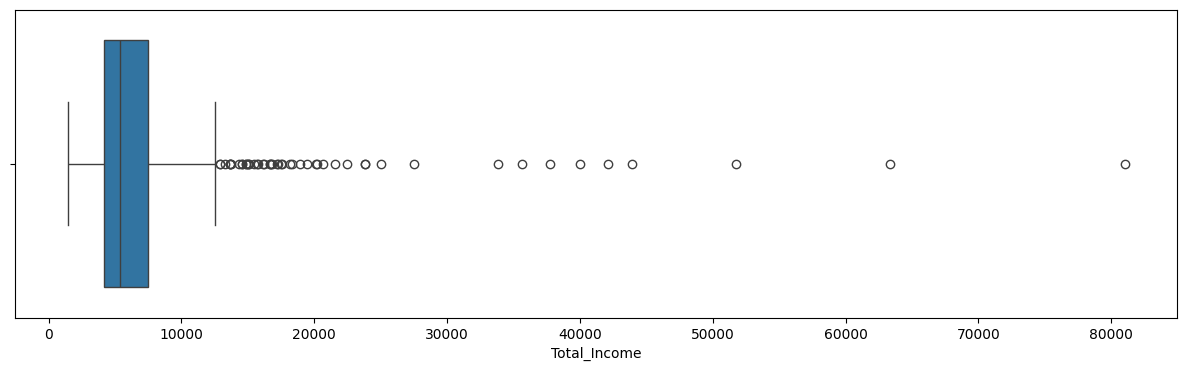

In [15]:
plt.figure(figsize=(15, 4))
sns.boxplot(x = 'Total_Income', data = df)
plt.show()

### Outlier Removal Using IQR Method

In [16]:
q1 = df["Total_Income"].quantile(0.25)
q3 = df["Total_Income"].quantile(0.75)
IQR = q3 - q1
IQR

np.float64(3355.75)

In [17]:
min_range = q1 - (1.5*IQR)
max_range = q3 + (1.5*IQR)
min_range, max_range

(np.float64(-867.625), np.float64(12555.375))

### Removing outliers from original data set

In [18]:
# We will accept those data which have less income than 'max_range' income
df = df[(df["Total_Income"] >= min_range) & (df["Total_Income"] <= max_range)]
df.head(2)

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,Male,No,0,Graduate,No,128.0,360.0,1.0,Urban,Y,5849.0
1,Male,Yes,1,Graduate,No,128.0,360.0,1.0,Rural,N,6091.0


In [19]:
df.shape # 564 rows

(564, 11)

In [20]:
# 614 - 564 = 50 rows removed

### After Handling outliers using IQR

C:\Users\user\AppData\Local\Temp\ipykernel_14960\4037175871.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Total_Income"])


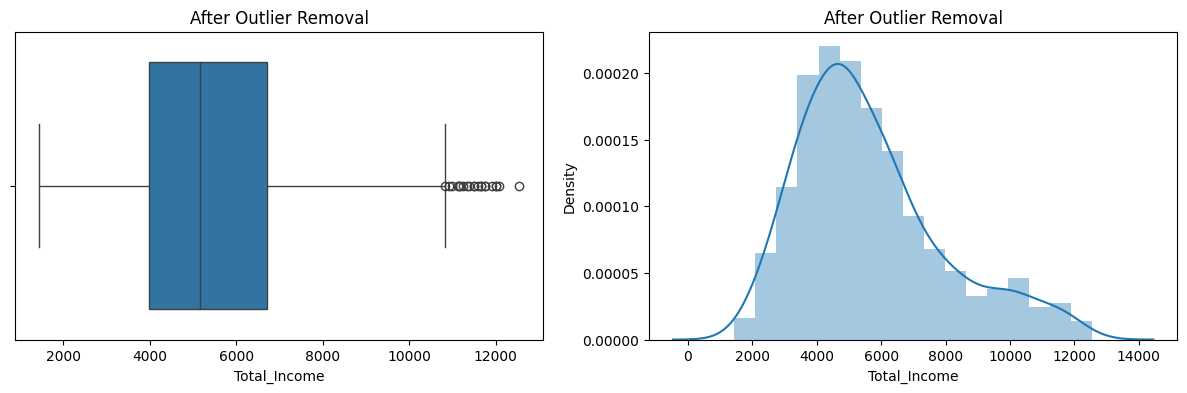

In [21]:
plt.figure(figsize=(15, 4))

# Checking outliers through boxplot
plt.subplot(1,2,1)
plt.title("After Outlier Removal")
sns.boxplot(x = 'Total_Income', data = df)

# Before Outlier Removal for 'x_train'
plt.subplot(1,2,2) # Means giving the just below plot in the 1st position (i.e. ( , ,1)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
plt.title("After Outlier Removal")
sns.distplot(df["Total_Income"])

plt.show()

# * FUNCTION TRANSFORMATION

#### * Function Transformation --> used when dataset is highly skewed
i) To convert a Non-Normal distribution data to a Normal Distribution data

ii) To change data pattern (E.g.: converting metre to cm, converting degree celsius to Kelvin, etc.)

#### For this loan.csv dataset, columns like:

LoanAmount, Total_Income

are usually skewed, so log transformation works well.

##### Benefits:
1) Handles skewed data
2) Reduces effect of large values
3) Avoids error when value = 0

In [22]:
from sklearn.preprocessing import FunctionTransformer

In [24]:
# Create transformer
log_transformer = FunctionTransformer(np.log1p)

# Apply on train and test
df['LoanAmount'] = log_transformer.fit_transform(df[['LoanAmount']])
df['Total_Income'] = log_transformer.fit_transform(df[['Total_Income']])

C:\Users\user\AppData\Local\Temp\ipykernel_14960\2673476071.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Total_Income"])
C:\Users\user\AppData\Local\Temp\ipykernel_14960\2673476071.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["LoanAmount"])


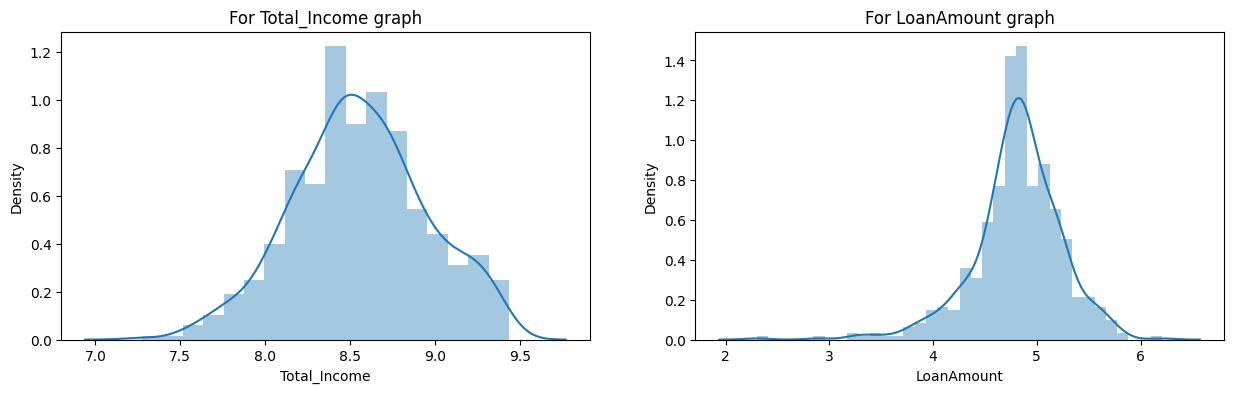

In [25]:
plt.figure(figsize=(15, 4))

# After Using FunctionTransformer on 'Total_Income'
plt.subplot(1,2,1)
plt.title("For Total_Income graph")
sns.distplot(df["Total_Income"])

# After Using FunctionTransformer on 'LoanAmount' for 'x_test'
plt.subplot(1,2,2)
plt.title("For LoanAmount graph")
sns.distplot(df["LoanAmount"])

plt.show()

#### NOTE:
We can apply function transformation on Loan_Amount_Term, but usually it is not recommended for this dataset.

##### Reason:
Loan_Amount_Term is typically a discrete duration variable (months like 12, 36, 60, 120, 180, 240, 360).

These are already structured intervals, not highly skewed continuous values.

Function transformations like log are most useful when data is strongly skewed.

##### For Loan_Amount_Term, transformation may not improve performance because:
1) Values are limited and repetitive
2) Distribution is often not heavily skewed
3) It behaves more like an ordinal/discrete feature

In [29]:
# still test it experimentally:

df['Loan_Amount_Term'] = np.log1p(df['Loan_Amount_Term'])
df['Loan_Amount_Term'] = np.log1p(df['Loan_Amount_Term'])

C:\Users\user\AppData\Local\Temp\ipykernel_14960\1795739169.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["LoanAmount"])


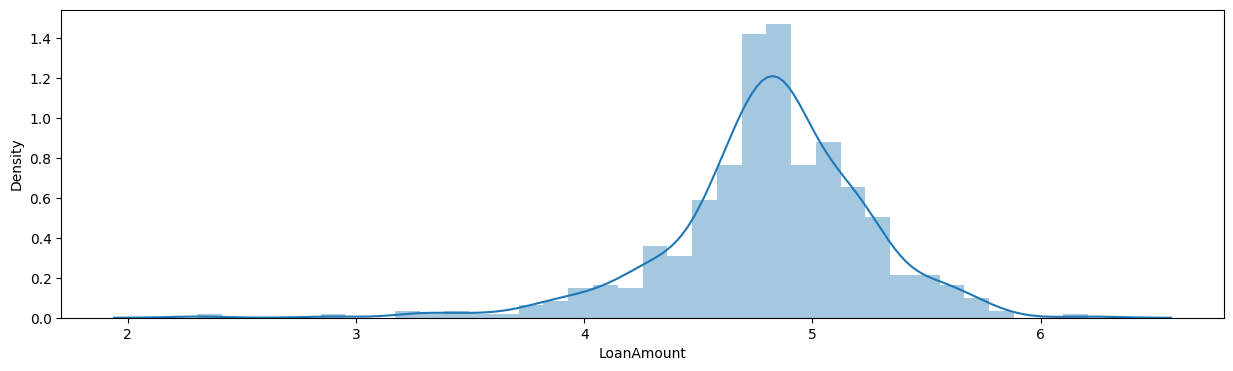

In [30]:
plt.figure(figsize=(15, 4))

# After Using FunctionTransformer on 'Loan_Amount_Term'
sns.distplot(df["LoanAmount"])
plt.show()

##### We observe that 'Tail' in both ends become longer, aso better not to apply 'Function Transformation' on 'Loan_Amount_Term'

#

#### NOTE:
When we know that removing OUTLIER can remove an important 'Feature' or 'Row for prediction,
then we can use the 'FunctionTransformer' without removing the outlier, and the graph would come as Normal Distribution curve